In [22]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import shap

# Configuration
BASE_PATH = r"C:\Users\gm733\OneDrive\Desktop\imageparkinson"  # Change to your path
IMG_SIZE = (256, 256)
N_SPLITS = 5
RANDOM_STATE = 42
USE_KNN_SEGMENTATION = False   # Set to True if you want KNN preprocessing (may slow down)
print("Setup complete.")

Setup complete.


In [23]:
def load_images_from_folders(root, subset='training'):
    """Load images from all drawing types (spiral, wave, drawings) under subset folder"""
    images, labels = [], []
    # Look for any subfolder that contains 'training' or 'testing'
    for drawing_type in os.listdir(root):
        subset_path = os.path.join(root, drawing_type, subset)
        if not os.path.isdir(subset_path):
            continue
        for label, cls in enumerate(['healthy', 'parkinson']):
            class_path = os.path.join(subset_path, cls)
            if not os.path.isdir(class_path):
                continue
            for fname in os.listdir(class_path):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img = cv2.imread(os.path.join(class_path, fname), cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        img = cv2.resize(img, IMG_SIZE)
                        images.append(img)
                        labels.append(label)
    return np.array(images), np.array(labels)

# Load training and test sets
X_train_raw, y_train = load_images_from_folders(BASE_PATH, subset='training')
X_test_raw, y_test = load_images_from_folders(BASE_PATH, subset='testing')

print(f"Training: {len(X_train_raw)} images | Healthy: {np.sum(y_train==0)} | PD: {np.sum(y_train==1)}")
print(f"Test: {len(X_test_raw)} images | Healthy: {np.sum(y_test==0)} | PD: {np.sum(y_test==1)}")

Training: 144 images | Healthy: 72 | PD: 72
Test: 60 images | Healthy: 30 | PD: 30


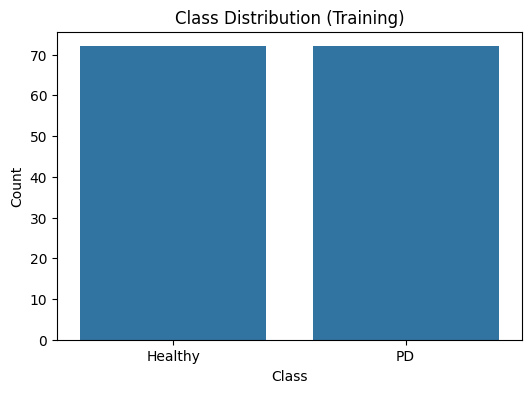

Healthy: 72
PD: 72


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Class Distribution (Training)")
plt.xticks([0,1], ['Healthy','PD'])
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print("Healthy:", np.sum(y_train==0))
print("PD:", np.sum(y_train==1))

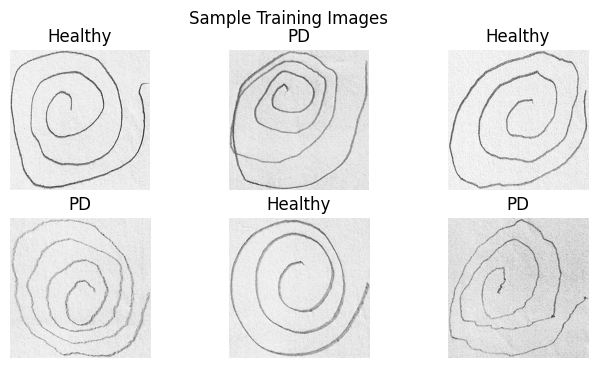

In [25]:
def show_samples(X, y, title):
    plt.figure(figsize=(8,4))
    for i in range(6):
        idx = np.where(y == i%2)[0][i]
        plt.subplot(2,3,i+1)
        plt.imshow(X[idx], cmap='gray')
        plt.title("Healthy" if y[idx]==0 else "PD")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_samples(X_train_raw, y_train, "Sample Training Images")

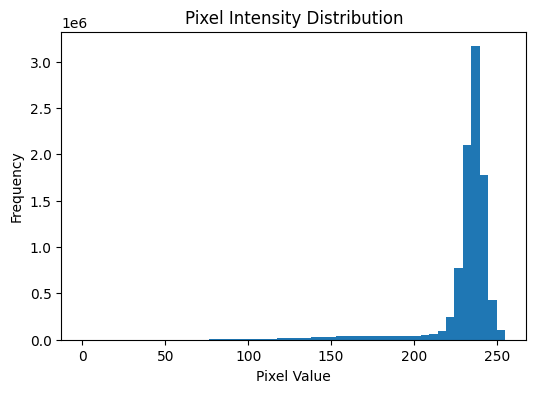

In [26]:
pixels = X_train_raw.flatten()

plt.figure(figsize=(6,4))
plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

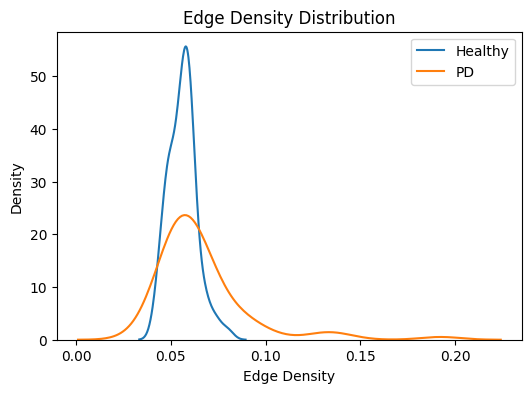

In [11]:
import cv2

def edge_density(img):
    edges = cv2.Canny(img,50,150)
    return np.sum(edges>0)/img.size

healthy_edges = [edge_density(img) for img in X_train_raw[y_train==0]]
pd_edges = [edge_density(img) for img in X_train_raw[y_train==1]]

plt.figure(figsize=(6,4))
sns.kdeplot(healthy_edges, label='Healthy')
sns.kdeplot(pd_edges, label='PD')
plt.title("Edge Density Distribution")
plt.xlabel("Edge Density")
plt.legend()
plt.show()

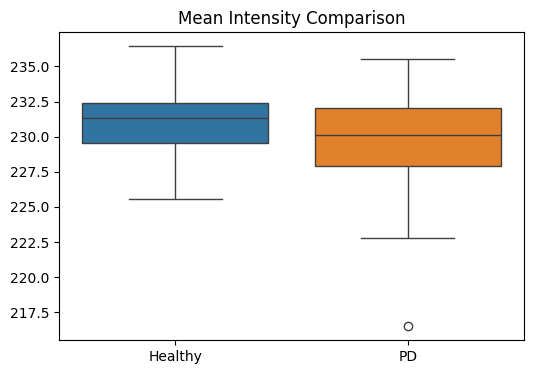

In [27]:
healthy_mean = [np.mean(img) for img in X_train_raw[y_train==0]]
pd_mean = [np.mean(img) for img in X_train_raw[y_train==1]]

plt.figure(figsize=(6,4))
sns.boxplot(data=[healthy_mean, pd_mean])
plt.xticks([0,1], ['Healthy','PD'])
plt.title("Mean Intensity Comparison")
plt.show()

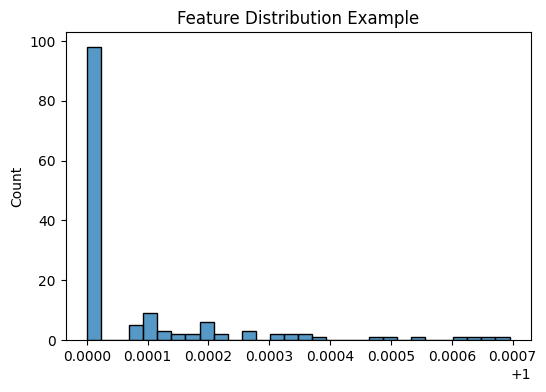

In [28]:
plt.figure(figsize=(6,4))
sns.histplot(X_train_geo[:,0], bins=30)
plt.title("Feature Distribution Example")
plt.show()

In [29]:
if USE_KNN_SEGMENTATION:
    from sklearn.neighbors import KNeighborsClassifier
    from skimage import morphology

    def knn_segment_and_extract(img, seed=42):
        np.random.seed(seed)
        h, w = img.shape
        grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        grad_mag = np.sqrt(grad_x**2 + grad_y**2)
        local_std = cv2.blur(img**2, (11,11)) - (cv2.blur(img, (11,11))**2)
        local_std = np.sqrt(np.maximum(local_std, 0))
        features = np.stack([img.ravel(), grad_mag.ravel(), local_std.ravel()], axis=1)
        
        _, pseudo_binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        pseudo_labels = (pseudo_binary // 255).ravel()
        sample_size = min(10000, len(features))
        sample_idx = np.random.choice(len(features), sample_size, replace=False)
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(features[sample_idx], pseudo_labels[sample_idx])
        
        pred_labels = knn.predict(features).reshape(h, w).astype(np.uint8)
        binary = pred_labels * 255
        skeleton = morphology.skeletonize(pred_labels).astype(np.uint8) * 255
        dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
        thickness = (dist * (skeleton//255)).astype(np.uint8)
        edges = cv2.Canny(binary, 50, 150)
        corners = cv2.goodFeaturesToTrack(img, 100, 0.01, 10)
        intersections = np.zeros_like(img)
        if corners is not None:
            for corner in corners:
                x, y = corner.ravel()
                intersections[int(y), int(x)] = 255
        return np.stack([thickness, edges, intersections], axis=-1)

    print("Extracting KNN feature maps (this may take a while)...")
    X_train_feat = np.array([knn_segment_and_extract(img) for img in X_train_raw])
    X_test_feat = np.array([knn_segment_and_extract(img) for img in X_test_raw])
    print("Feature maps shape:", X_train_feat.shape)
else:
    # Simple preprocessing: just normalise raw grayscale to [0,1] and convert to 3 channels for pretrained models
    # For custom CNN, we will keep 1 channel.
    def normalize(img):
        return img.astype('float32') / 255.0
    
    # For DL models that need 3 channels, we'll convert later.
    # For now, store raw normalized grayscale
    X_train_norm = np.array([normalize(img) for img in X_train_raw])
    X_test_norm = np.array([normalize(img) for img in X_test_raw])
    # For compatibility, we'll treat X_train_feat as the normalized grayscale (1 channel)
    X_train_feat = np.expand_dims(X_train_norm, axis=-1)   # shape (n,256,256,1)
    X_test_feat = np.expand_dims(X_test_norm, axis=-1)
    print("Normalized grayscale images shape:", X_train_feat.shape)

Normalized grayscale images shape: (144, 256, 256, 1)


In [30]:
def geometric_features(img):
    edges = cv2.Canny(img, 50, 150)
    dist = cv2.distanceTransform(edges, cv2.DIST_L2, 5)
    mean_thick = np.mean(dist[edges>0]) if np.any(edges) else 0
    std_thick = np.std(dist[edges>0]) if np.any(edges) else 0
    num_pixels = np.sum(edges>0)
    edgepoints = cv2.Canny(img, 100, 200)
    num_edgepoints = np.sum(edgepoints>0)
    corners = cv2.goodFeaturesToTrack(img, 100, 0.01, 10)
    num_intersections = len(corners) if corners is not None else 0
    return [mean_thick, std_thick, num_pixels, num_edgepoints, num_intersections]

X_train_geo = np.array([geometric_features(img) for img in X_train_raw])
X_test_geo = np.array([geometric_features(img) for img in X_test_raw])
print("Geometric features shape:", X_train_geo.shape)

Geometric features shape: (144, 5)


In [31]:
# ML models (use geometric features)
ml_models = {
    'RF': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'XGB': xgb.XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss'),
    'DT': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'NB': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Custom CNN (1 channel input)
def build_cnn():
    model = models.Sequential([
        layers.Input(shape=(256,256,1)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2), layers.Dropout(0.25),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2), layers.Dropout(0.25),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2), layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation='relu'), layers.Dropout(0.25),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# VGG16 (3 channels) – convert grayscale to RGB inside model
def build_vgg():
    base = applications.VGG16(weights='imagenet', include_top=False, input_shape=(256,256,3))
    base.trainable = False
    # Add a layer to convert 1-channel to 3-channel by repeating
    inputs = layers.Input(shape=(256,256,1))
    x = layers.Conv2D(3, (1,1), padding='same', use_bias=False)(inputs)  # map 1->3 channels
    x = base(x)
    x = layers.Flatten()(x)
    x = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs=inputs, outputs=x)

# ResNet50 (3 channels)
def build_resnet():
    base = applications.ResNet50(weights='imagenet', include_top=False, input_shape=(256,256,3))
    base.trainable = False
    inputs = layers.Input(shape=(256,256,1))
    x = layers.Conv2D(3, (1,1), padding='same', use_bias=False)(inputs)
    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs=inputs, outputs=x)

# AlexNet (custom, 3 channels)
def build_alexnet():
    inputs = layers.Input(shape=(256,256,1))
    x = layers.Conv2D(3, (1,1), padding='same', use_bias=False)(inputs)
    x = layers.Conv2D(96, (11,11), strides=4, activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=(3,3), strides=2)(x)
    x = layers.Conv2D(256, (5,5), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=(3,3), strides=2)(x)
    x = layers.Conv2D(384, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(384, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=(3,3), strides=2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(4096, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(4096, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs=inputs, outputs=x)

all_models_names = list(ml_models.keys()) + ['CNN', 'VGG', 'ResNet', 'AlexNet']
print("Models defined:", all_models_names)

Models defined: ['RF', 'SVM', 'XGB', 'DT', 'NB', 'KNN', 'CNN', 'VGG', 'ResNet', 'AlexNet']


In [32]:
results_cv = {name: {'acc':[], 'prec':[], 'rec':[], 'f1':[]} for name in all_models_names}
all_probs_cv = {name: [] for name in all_models_names}
all_true_cv = {name: [] for name in all_models_names}
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
print("CV storage ready.")

CV storage ready.



ML CROSS VALIDATION START

FOLD 1/5

Model: RF
Accuracy : 0.7931
Precision: 0.8333
Recall   : 0.7143
F1 Score : 0.7692


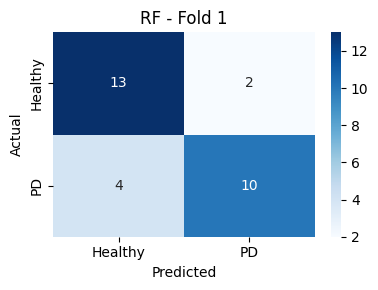


Model: SVM
Accuracy : 0.6207
Precision: 1.0000
Recall   : 0.2143
F1 Score : 0.3529


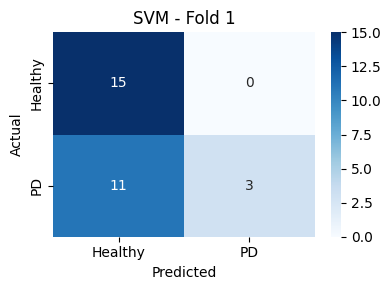


Model: XGB
Accuracy : 0.6207
Precision: 0.6000
Recall   : 0.6429
F1 Score : 0.6207


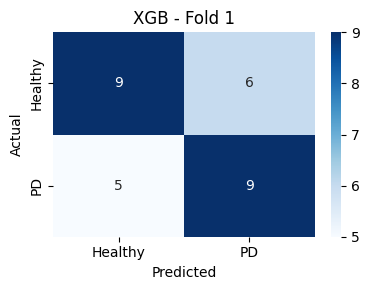


Model: DT
Accuracy : 0.5517
Precision: 0.5385
Recall   : 0.5000
F1 Score : 0.5185


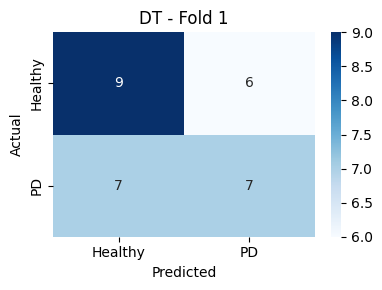


Model: NB
Accuracy : 0.4828
Precision: 0.4828
Recall   : 1.0000
F1 Score : 0.6512


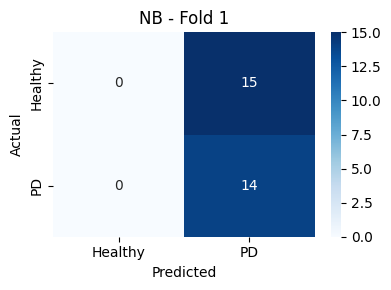


Model: KNN
Accuracy : 0.7931
Precision: 0.8333
Recall   : 0.7143
F1 Score : 0.7692


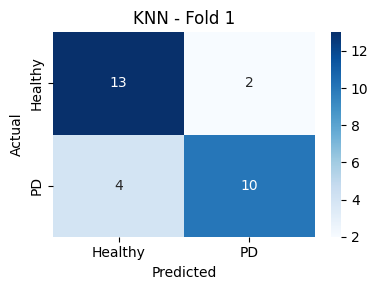


FOLD 2/5

Model: RF
Accuracy : 0.6207
Precision: 0.5882
Recall   : 0.7143
F1 Score : 0.6452


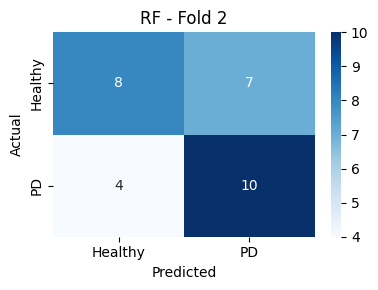


Model: SVM
Accuracy : 0.6552
Precision: 0.6667
Recall   : 0.5714
F1 Score : 0.6154


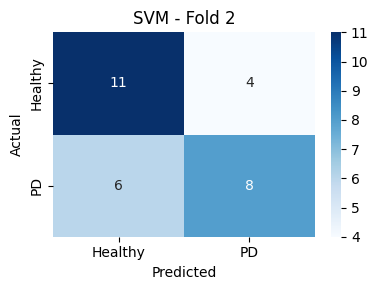


Model: XGB
Accuracy : 0.5517
Precision: 0.5263
Recall   : 0.7143
F1 Score : 0.6061


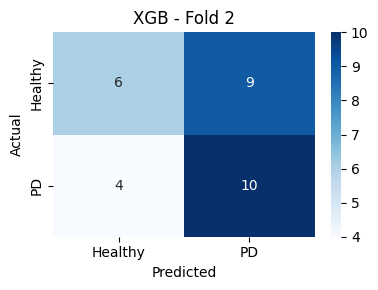


Model: DT
Accuracy : 0.5862
Precision: 0.5714
Recall   : 0.5714
F1 Score : 0.5714


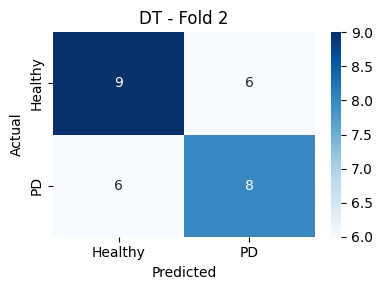


Model: NB
Accuracy : 0.4828
Precision: 0.4828
Recall   : 1.0000
F1 Score : 0.6512


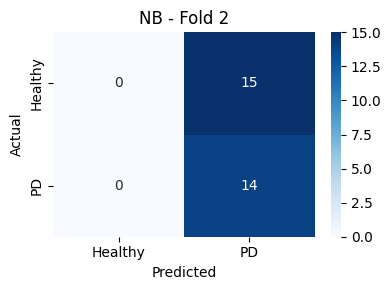


Model: KNN
Accuracy : 0.7931
Precision: 0.8333
Recall   : 0.7143
F1 Score : 0.7692


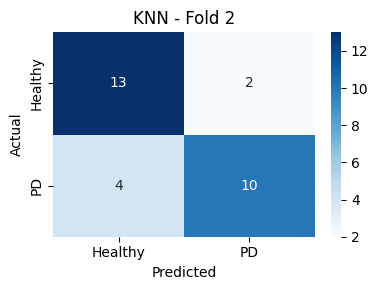


FOLD 3/5

Model: RF
Accuracy : 0.5172
Precision: 0.5556
Recall   : 0.3333
F1 Score : 0.4167


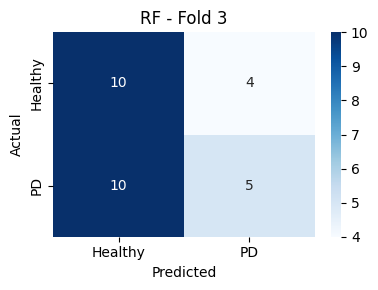


Model: SVM
Accuracy : 0.5172
Precision: 1.0000
Recall   : 0.0667
F1 Score : 0.1250


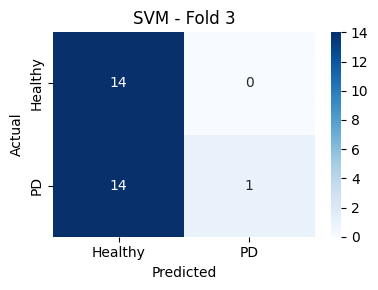


Model: XGB
Accuracy : 0.6552
Precision: 0.7273
Recall   : 0.5333
F1 Score : 0.6154


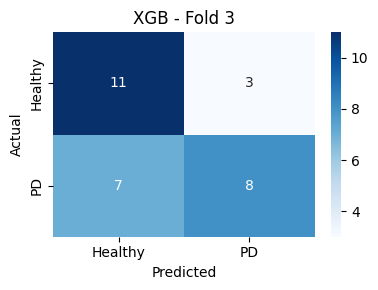


Model: DT
Accuracy : 0.5517
Precision: 0.5833
Recall   : 0.4667
F1 Score : 0.5185


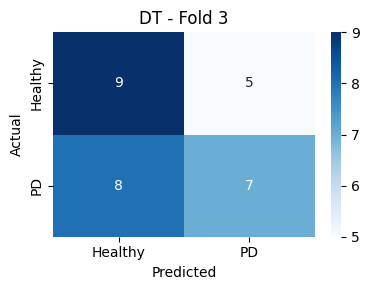


Model: NB
Accuracy : 0.5172
Precision: 0.5172
Recall   : 1.0000
F1 Score : 0.6818


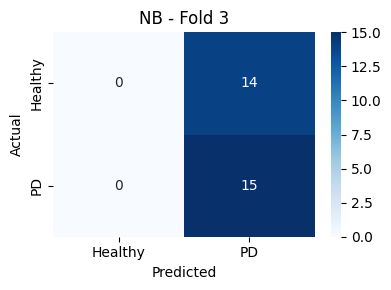


Model: KNN
Accuracy : 0.5172
Precision: 0.5556
Recall   : 0.3333
F1 Score : 0.4167


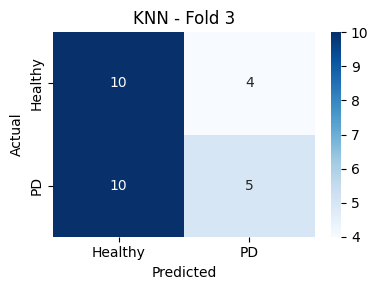


FOLD 4/5

Model: RF
Accuracy : 0.5862
Precision: 0.5714
Recall   : 0.8000
F1 Score : 0.6667


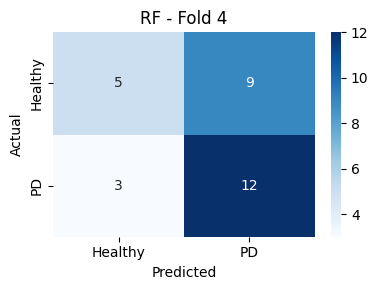


Model: SVM
Accuracy : 0.6207
Precision: 0.7500
Recall   : 0.4000
F1 Score : 0.5217


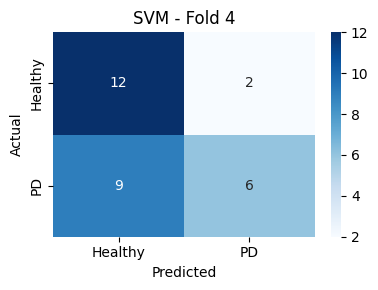


Model: XGB
Accuracy : 0.5517
Precision: 0.5556
Recall   : 0.6667
F1 Score : 0.6061


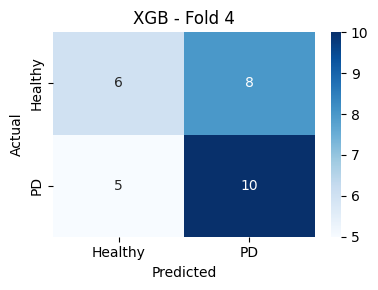


Model: DT
Accuracy : 0.5517
Precision: 0.5500
Recall   : 0.7333
F1 Score : 0.6286


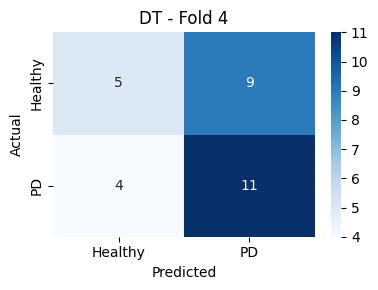


Model: NB
Accuracy : 0.5517
Precision: 0.5357
Recall   : 1.0000
F1 Score : 0.6977


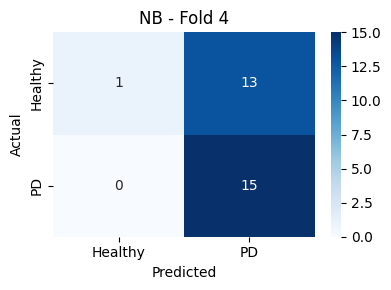


Model: KNN
Accuracy : 0.6552
Precision: 0.6471
Recall   : 0.7333
F1 Score : 0.6875


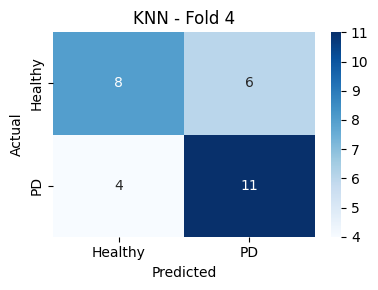


FOLD 5/5

Model: RF
Accuracy : 0.6071
Precision: 0.5882
Recall   : 0.7143
F1 Score : 0.6452


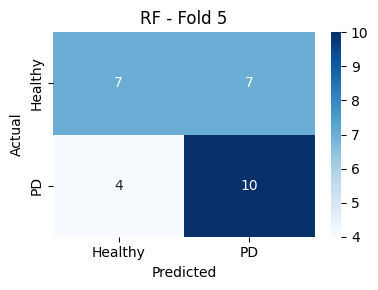


Model: SVM
Accuracy : 0.6071
Precision: 1.0000
Recall   : 0.2143
F1 Score : 0.3529


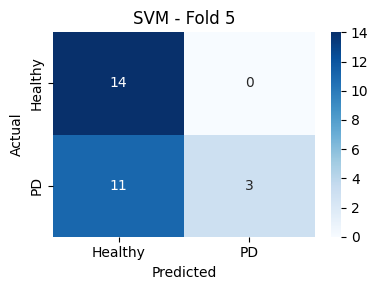


Model: XGB
Accuracy : 0.5000
Precision: 0.5000
Recall   : 0.5000
F1 Score : 0.5000


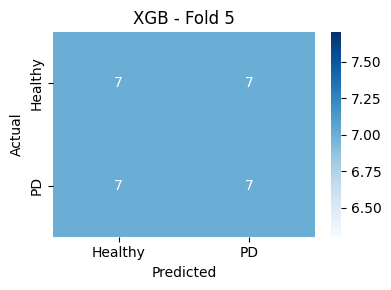


Model: DT
Accuracy : 0.5714
Precision: 0.5625
Recall   : 0.6429
F1 Score : 0.6000


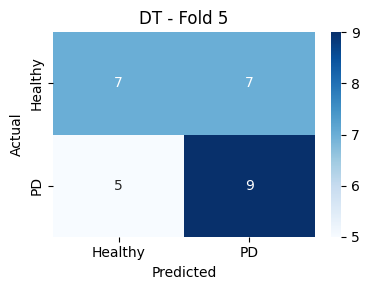


Model: NB
Accuracy : 0.5357
Precision: 0.5185
Recall   : 1.0000
F1 Score : 0.6829


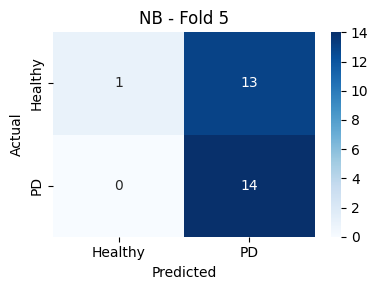


Model: KNN
Accuracy : 0.6429
Precision: 0.6250
Recall   : 0.7143
F1 Score : 0.6667


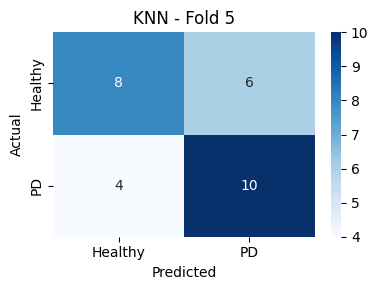


CROSS VALIDATION COMPLETED

FINAL AVERAGE RESULTS

RF
  Accuracy : 0.6249
  Precision: 0.6274
  Recall   : 0.6552
  F1 Score : 0.6286
----------------------------------------
SVM
  Accuracy : 0.6042
  Precision: 0.8833
  Recall   : 0.2933
  F1 Score : 0.3936
----------------------------------------
XGB
  Accuracy : 0.5759
  Precision: 0.5818
  Recall   : 0.6114
  F1 Score : 0.5896
----------------------------------------
DT
  Accuracy : 0.5626
  Precision: 0.5611
  Recall   : 0.5829
  F1 Score : 0.5674
----------------------------------------
NB
  Accuracy : 0.5140
  Precision: 0.5074
  Recall   : 1.0000
  F1 Score : 0.6729
----------------------------------------
KNN
  Accuracy : 0.6803
  Precision: 0.6989
  Recall   : 0.6419
  F1 Score : 0.6619
----------------------------------------


In [33]:
# ================= FULL ML CROSS VALIDATION =================

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- MODEL NAMES ----------------
all_model_names = list(ml_models.keys())

# ---------------- STORAGE ----------------
results_cv = {
    n: {'acc': [], 'prec': [], 'rec': [], 'f1': []}
    for n in all_model_names
}

all_probs_cv = {n: [] for n in all_model_names}
all_true_cv = {n: [] for n in all_model_names}

print("\n" + "="*60)
print("ML CROSS VALIDATION START")
print("="*60)

# ---------------- K-FOLD ----------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------- LOOP ----------------
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_geo, y_train)):

    print(f"\n{'='*60}")
    print(f"FOLD {fold+1}/5")
    print(f"{'='*60}")

    # Split labels
    y_train_fold = y_train[train_idx]
    y_val_fold = y_train[val_idx]

    # Split features
    X_train_fold = X_train_geo[train_idx]
    X_val_fold = X_train_geo[val_idx]

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_val_scaled = scaler.transform(X_val_fold)

    # ---------------- MODELS ----------------
    for name, model in ml_models.items():

        print(f"\nModel: {name}")

        # Train
        model.fit(X_train_scaled, y_train_fold)

        # Predict
        y_pred = model.predict(X_val_scaled)

        # Metrics
        acc = accuracy_score(y_val_fold, y_pred)
        prec = precision_score(y_val_fold, y_pred, zero_division=0)
        rec = recall_score(y_val_fold, y_pred, zero_division=0)
        f1 = f1_score(y_val_fold, y_pred, zero_division=0)

        # Store
        results_cv[name]['acc'].append(acc)
        results_cv[name]['prec'].append(prec)
        results_cv[name]['rec'].append(rec)
        results_cv[name]['f1'].append(f1)

        # Probability
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_val_scaled)[:, 1]
        else:
            y_prob = model.decision_function(X_val_scaled)
            y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-8)

        all_probs_cv[name].extend(y_prob)
        all_true_cv[name].extend(y_val_fold)

        # Print metrics
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1 Score : {f1:.4f}")

        # ---------------- CONFUSION MATRIX ----------------
        cm = confusion_matrix(y_val_fold, y_pred)

        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Healthy','PD'],
                    yticklabels=['Healthy','PD'])
        plt.title(f'{name} - Fold {fold+1}')
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

print("\n" + "="*60)
print("CROSS VALIDATION COMPLETED")
print("="*60)

# ---------------- FINAL AVERAGE RESULTS ----------------
print("\nFINAL AVERAGE RESULTS\n")

for name in all_model_names:
    avg_acc = np.mean(results_cv[name]['acc'])
    avg_prec = np.mean(results_cv[name]['prec'])
    avg_rec = np.mean(results_cv[name]['rec'])
    avg_f1 = np.mean(results_cv[name]['f1'])

    print(f"{name}")
    print(f"  Accuracy : {avg_acc:.4f}")
    print(f"  Precision: {avg_prec:.4f}")
    print(f"  Recall   : {avg_rec:.4f}")
    print(f"  F1 Score : {avg_f1:.4f}")
    print("-"*40)

In [34]:
import cv2
import numpy as np

IMG_SIZE = (128,128)

def prepare_dl_data(X_raw):
    X_out = []
    for img in X_raw:
        img = cv2.resize(img, IMG_SIZE)
        img = img.astype('float32') / 255.0
        img = np.expand_dims(img, axis=-1)   # (128,128,1)
        X_out.append(img)
    return np.array(X_out)

# IMPORTANT: use your raw images
X_train_cnn = prepare_dl_data(X_train_raw)

# reuse same for all models
X_train_vgg = X_train_cnn.copy()
X_train_res = X_train_cnn.copy()
X_train_alex = X_train_cnn.copy()

In [35]:
import tensorflow as tf
from tensorflow.keras import layers, models

# -------- CNN --------
def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,1)),
        layers.MaxPooling2D(),
        layers.Conv2D(64,(3,3),activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128,activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1,activation='sigmoid')
    ])
    return model

# -------- VGG (SIMPLIFIED) --------
def build_vgg():
    model = models.Sequential([
        layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,1)),
        layers.Conv2D(32,(3,3),activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64,(3,3),activation='relu'),
        layers.Conv2D(64,(3,3),activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256,activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1,activation='sigmoid')
    ])
    return model

# -------- RESNET (LIGHT) --------
def build_resnet():
    inputs = tf.keras.Input(shape=(128,128,1))

    x = layers.Conv2D(32,3,padding='same',activation='relu')(inputs)
    skip = x

    x = layers.Conv2D(32,3,padding='same',activation='relu')(x)
    x = layers.Add()([x, skip])

    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128,activation='relu')(x)
    outputs = layers.Dense(1,activation='sigmoid')(x)

    return tf.keras.Model(inputs, outputs)

# -------- ALEXNET (FIXED) --------
def build_alexnet():
    model = models.Sequential([
        layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,1)),
        layers.MaxPooling2D(),
        layers.Conv2D(64,(3,3),activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256,activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1,activation='sigmoid')
    ])
    return model

In [36]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dl_models = {
    'CNN': (X_train_cnn, build_cnn),
    'VGG': (X_train_vgg, build_vgg),
    'ResNet': (X_train_res, build_resnet),
    'AlexNet': (X_train_alex, build_alexnet)
}

results_dl = {k:{'acc':[], 'prec':[], 'rec':[], 'f1':[]} for k in dl_models.keys()}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold,(train_idx,val_idx) in enumerate(skf.split(X_train_cnn, y_train)):

    print(f"\nFOLD {fold+1}")

    y_tr = y_train[train_idx]
    y_val = y_train[val_idx]

    for name,(X_data,builder) in dl_models.items():

        print(f"\n{name}")

        X_tr = X_data[train_idx]
        X_val = X_data[val_idx]

        model = builder()

        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        model.fit(
            X_tr, y_tr,
            epochs=50,
            batch_size=16,
            validation_data=(X_val, y_val),
            verbose=0
        )

        y_prob = model.predict(X_val, verbose=0).flatten()
        y_pred = (y_prob > 0.5).astype(int)

        acc = accuracy_score(y_val,y_pred)
        prec = precision_score(y_val,y_pred,zero_division=0)
        rec = recall_score(y_val,y_pred,zero_division=0)
        f1 = f1_score(y_val,y_pred,zero_division=0)

        results_dl[name]['acc'].append(acc)
        results_dl[name]['prec'].append(prec)
        results_dl[name]['rec'].append(rec)
        results_dl[name]['f1'].append(f1)

        print(f"Acc: {acc:.4f}")


FOLD 1

CNN


c:\Users\gm733\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Acc: 0.4828

VGG


c:\Users\gm733\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Acc: 0.4828

ResNet
Acc: 0.5517

AlexNet


...

Acc: 0.7857

VGG


c:\Users\gm733\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Acc: 0.6429

ResNet
Acc: 0.6786

AlexNet


c:\Users\gm733\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Acc: 0.7143


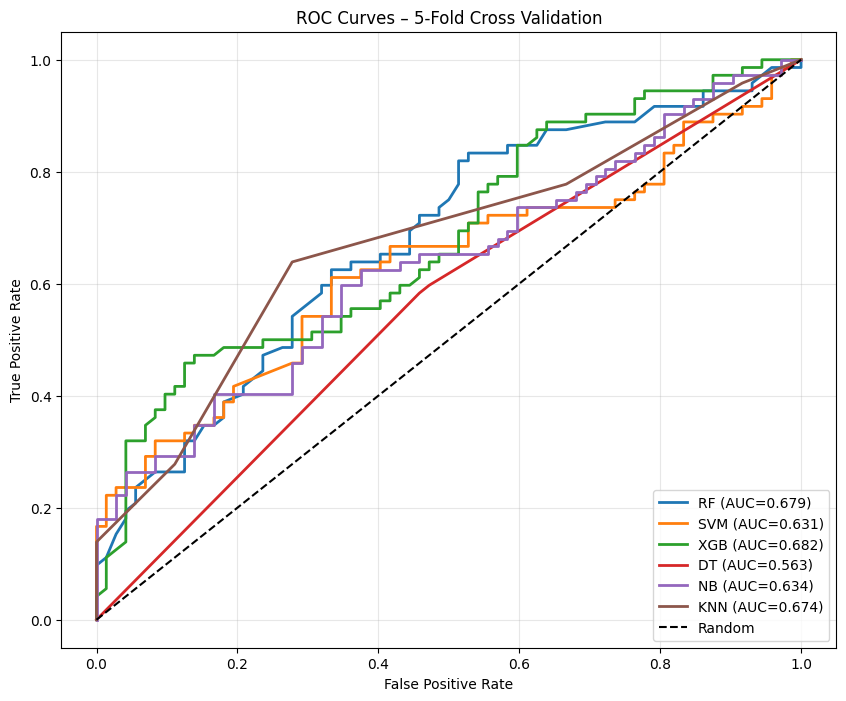


CROSS-VALIDATION RESULTS (5-FOLD)
Model        Accuracy Precision Recall F1 Score
   RF 0.6249 ± 0.0913    0.6274 0.6552   0.6286
  SVM 0.6042 ± 0.0463    0.8833 0.2933   0.3936
  XGB 0.5759 ± 0.0552    0.5818 0.6114   0.5896
   DT 0.5626 ± 0.0141    0.5611 0.5829   0.5674
   NB 0.5140 ± 0.0278    0.5074 1.0000   0.6729
  KNN 0.6803 ± 0.1040    0.6989 0.6419   0.6619


In [39]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ================= ROC CURVE =================
plt.figure(figsize=(10,8))
auc_cv = {}

for name in results_cv.keys():

    # Skip if no data
    if len(all_probs_cv[name]) == 0:
        continue

    y_true = np.array(all_true_cv[name])
    y_prob = np.array(all_probs_cv[name])

    # Skip if only one class
    if len(np.unique(y_true)) < 2:
        continue

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    auc_cv[name] = roc_auc

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc:.3f})')

# Random baseline
plt.plot([0,1], [0,1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – 5-Fold Cross Validation')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


# ================= CV SUMMARY TABLE =================
cv_summary = []

for name in results_cv.keys():

    mean_acc = np.mean(results_cv[name]['acc'])
    std_acc  = np.std(results_cv[name]['acc'])

    cv_summary.append({
        'Model': name,
        'Accuracy': f"{mean_acc:.4f} ± {std_acc:.4f}",
        'Precision': f"{np.mean(results_cv[name]['prec']):.4f}",
        'Recall': f"{np.mean(results_cv[name]['rec']):.4f}",
        'F1 Score': f"{np.mean(results_cv[name]['f1']):.4f}"
    })

df_cv = pd.DataFrame(cv_summary)

print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS (5-FOLD)")
print("="*80)
print(df_cv.to_string(index=False))


Training RF...


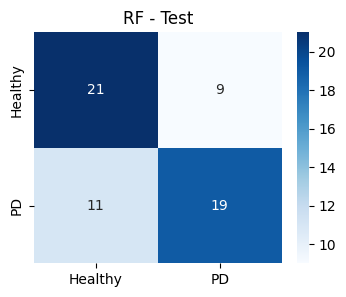


Training SVM...


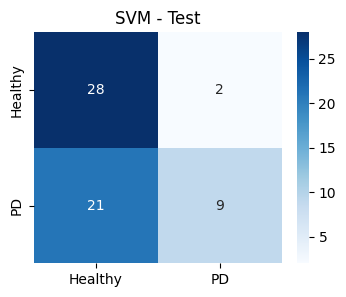


Training XGB...


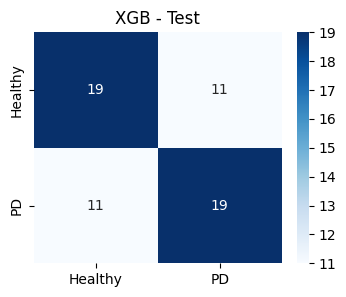


Training DT...


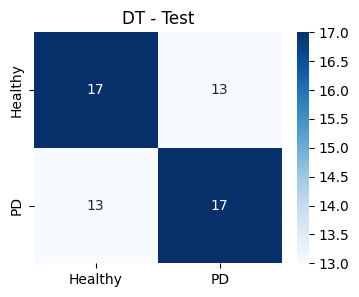


Training NB...


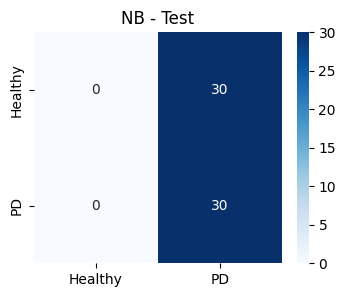


Training KNN...


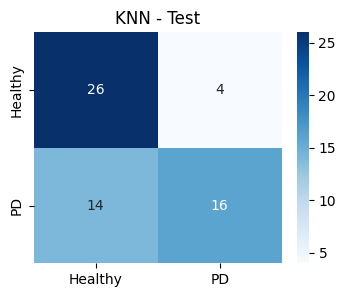

c:\Users\gm733\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training CNN...
Epoch 1/50


c:\Users\gm733\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.5426 - loss: 1.3318 - val_accuracy: 0.4667 - val_loss: 0.7382
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.5349 - loss: 0.7188 - val_accuracy: 0.5333 - val_loss: 0.6929
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.4884 - loss: 0.6936 - val_accuracy: 0.4667 - val_loss: 0.6935
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.5039 - loss: 0.6930 - val_accuracy: 0.4667 - val_loss: 0.6936
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.5039 - loss: 0.6931 - val_accuracy: 0.4667 - val_loss: 0.6934
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.5504 - loss: 0.6930 - val_accuracy: 0.4667 - val_loss: 0.6933
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.4264 - loss: 0.6933 - val_accuracy: 0.5333 - val_loss: 0.6931


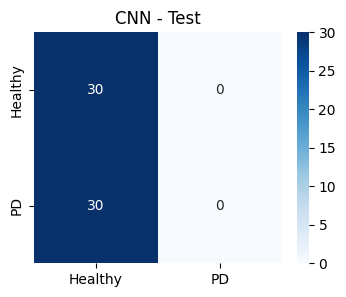


Training VGG...
Epoch 1/50


c:\Users\gm733\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - accuracy: 0.4651 - loss: 1.5205 - val_accuracy: 0.5333 - val_loss: 0.6914
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - accuracy: 0.5426 - loss: 0.6934 - val_accuracy: 0.4667 - val_loss: 0.7059
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step - accuracy: 0.4884 - loss: 0.7009 - val_accuracy: 0.4667 - val_loss: 0.6931
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.5039 - loss: 0.6965 - val_accuracy: 0.4667 - val_loss: 0.6934
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - accuracy: 0.5039 - loss: 0.6976 - val_accuracy: 0.4667 - val_loss: 0.6944
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step - accuracy: 0.4961 - loss: 0.6952 - val_accuracy: 0.4667 - val_loss: 0.6962


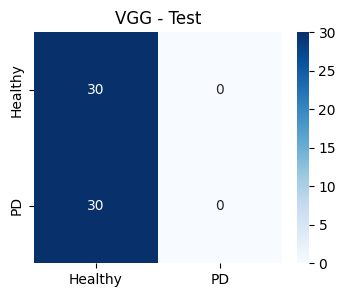


Training ResNet...
Epoch 1/50


c:\Users\gm733\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.5426 - loss: 8.1451 - val_accuracy: 0.5333 - val_loss: 1.0593
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - accuracy: 0.4651 - loss: 0.9975 - val_accuracy: 0.4667 - val_loss: 0.7717
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - accuracy: 0.5194 - loss: 0.7063 - val_accuracy: 0.5333 - val_loss: 0.6906
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - accuracy: 0.4651 - loss: 0.7282 - val_accuracy: 0.5333 - val_loss: 0.7784
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step - accuracy: 0.5814 - loss: 0.8162 - val_accuracy: 0.4667 - val_loss: 1.5010
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - accuracy: 0.4961 - loss: 1.0992 - val_accuracy: 0.5333 - val_loss: 0.9682
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.4341 - loss: 0.9601 - val_accuracy: 0.4667 - val_loss: 0.9444
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - accuracy: 0.4341 - loss: 0.8610 - val_accuracy: 0.5333 - val_loss: 0.8099


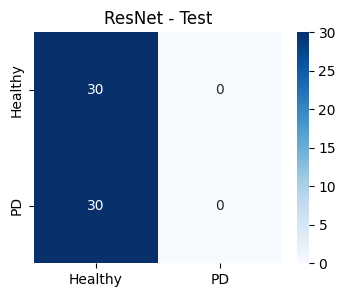


Training AlexNet...
Epoch 1/50


c:\Users\gm733\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - accuracy: 0.5504 - loss: 1.6493 - val_accuracy: 0.4667 - val_loss: 0.6949
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.4961 - loss: 0.7029 - val_accuracy: 0.4667 - val_loss: 0.6934
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.5194 - loss: 0.6968 - val_accuracy: 0.4667 - val_loss: 0.6960
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.4884 - loss: 0.6944 - val_accuracy: 0.4667 - val_loss: 0.6935
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.5116 - loss: 0.6939 - val_accuracy: 0.6667 - val_loss: 0.6928
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.5426 - loss: 0.6929 - val_accuracy: 0.5333 - val_loss: 0.6927
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - accuracy: 0.4961 - loss: 0.6932 - val_accuracy: 0.5333 - val_loss: 0.6927
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.4961 - loss: 0.6933 - val_accuracy: 0.5333 - val_loss: 0.6927
Epo

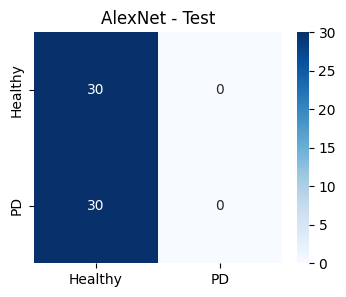


FINAL TEST RESULTS
  Model Accuracy Precision Recall     F1
     RF   0.6667    0.6786 0.6333 0.6552
    SVM   0.6167    0.8182 0.3000 0.4390
    XGB   0.6333    0.6333 0.6333 0.6333
     DT   0.5667    0.5667 0.5667 0.5667
     NB   0.5000    0.5000 1.0000 0.6667
    KNN   0.7000    0.8000 0.5333 0.6400
    CNN   0.5000    0.0000 0.0000 0.0000
    VGG   0.5000    0.0000 0.0000 0.0000
 ResNet   0.5000    0.0000 0.0000 0.0000
AlexNet   0.5000    0.0000 0.0000 0.0000


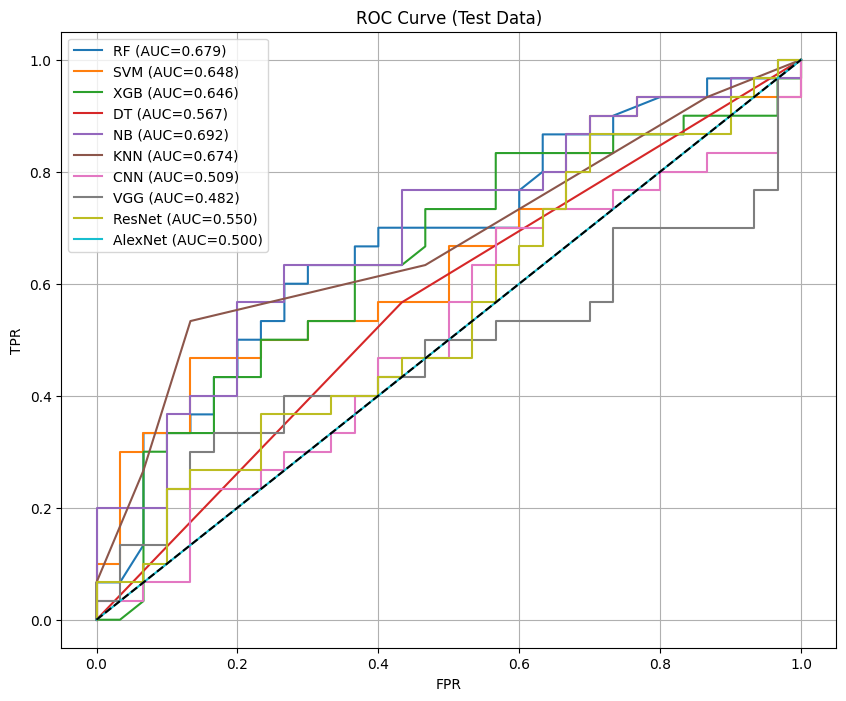

In [40]:
# ================= FINAL TRAIN + TEST PIPELINE =================

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# ---------------- FIX DL INPUT ----------------
def resize_for_dl(X):
    X_out = []
    for img in X:
        img = cv2.resize(img, (128,128))
        img = img.astype('float32') / 255.0
        img = np.expand_dims(img, axis=-1)
        X_out.append(img)
    return np.array(X_out)

# ---------------- PREPARE DATA ----------------
X_train_full_geo = X_train_geo
X_test_full_geo  = X_test_geo

scaler_full = StandardScaler()
X_train_full_geo_scaled = scaler_full.fit_transform(X_train_full_geo)
X_test_full_geo_scaled  = scaler_full.transform(X_test_full_geo)

# DL data (FIXED)
X_train_full_feat = resize_for_dl(X_train_raw)
X_test_full_feat  = resize_for_dl(X_test_raw)

# ---------------- RESULTS STORAGE ----------------
all_models_names = list(ml_models.keys()) + ['CNN','VGG','ResNet','AlexNet']

test_results = {name: {'acc':0,'prec':0,'rec':0,'f1':0} for name in all_models_names}
test_probs = {}

# ================= ML MODELS =================
for name, model in ml_models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train_full_geo_scaled, y_train)

    y_pred = model.predict(X_test_full_geo_scaled)

    test_results[name]['acc'] = accuracy_score(y_test, y_pred)
    test_results[name]['prec'] = precision_score(y_test, y_pred, zero_division=0)
    test_results[name]['rec'] = recall_score(y_test, y_pred, zero_division=0)
    test_results[name]['f1'] = f1_score(y_test, y_pred, zero_division=0)

    # Probabilities
    if hasattr(model,"predict_proba"):
        y_prob = model.predict_proba(X_test_full_geo_scaled)[:,1]
    else:
        y_prob = model.decision_function(X_test_full_geo_scaled)
        y_prob = (y_prob - y_prob.min())/(y_prob.max()-y_prob.min()+1e-8)

    test_probs[name] = y_prob

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Healthy','PD'], yticklabels=['Healthy','PD'])
    plt.title(f'{name} - Test')
    plt.show()

# ================= DL MODELS =================
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_full_feat, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

def build_all_dl_models():
    return {
        'CNN': build_cnn(),
        'VGG': build_vgg(),
        'ResNet': build_resnet(),
        'AlexNet': build_alexnet()
    }

for name, model in build_all_dl_models().items():

    print(f"\nTraining {name}...")

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    datagen = ImageDataGenerator(
        rotation_range=15,
        zoom_range=0.1,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True
    )

    train_gen = datagen.flow(X_train_split, y_train_split, batch_size=16)

    early_stop = EarlyStopping(patience=5, restore_best_weights=True)

    model.fit(train_gen,
              epochs=50,
              validation_data=(X_val_split, y_val_split),
              callbacks=[early_stop],
              verbose=1)

    y_prob = model.predict(X_test_full_feat, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)

    test_results[name]['acc'] = accuracy_score(y_test, y_pred)
    test_results[name]['prec'] = precision_score(y_test, y_pred, zero_division=0)
    test_results[name]['rec'] = recall_score(y_test, y_pred, zero_division=0)
    test_results[name]['f1'] = f1_score(y_test, y_pred, zero_division=0)

    test_probs[name] = y_prob

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Healthy','PD'], yticklabels=['Healthy','PD'])
    plt.title(f'{name} - Test')
    plt.show()

# ================= RESULTS TABLE =================
summary = []
for name in test_results.keys():
    summary.append({
        'Model': name,
        'Accuracy': f"{test_results[name]['acc']:.4f}",
        'Precision': f"{test_results[name]['prec']:.4f}",
        'Recall': f"{test_results[name]['rec']:.4f}",
        'F1': f"{test_results[name]['f1']:.4f}"
    })

df = pd.DataFrame(summary)
print("\nFINAL TEST RESULTS")
print(df.to_string(index=False))

# ================= ROC CURVE =================
plt.figure(figsize=(10,8))

for name in test_probs.keys():

    y_prob = test_probs[name]

    if len(np.unique(y_test)) < 2:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Test Data)")
plt.legend()
plt.grid()
plt.show()

Best tree model on test set: RF (accuracy=0.6667)


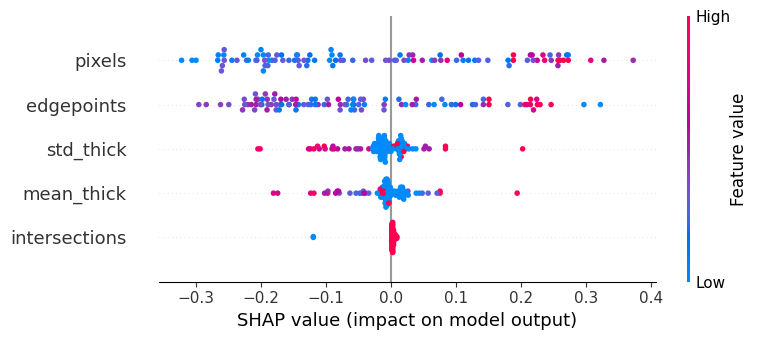

In [42]:
tree_models = ['RF', 'XGB', 'DT']
best_tree = None
best_acc = -1
for name in tree_models:
    acc = test_results[name]['acc']
    if acc > best_acc:
        best_acc = acc
        best_tree = name

if best_tree:
    print(f"Best tree model on test set: {best_tree} (accuracy={best_acc:.4f})")
    model = ml_models[best_tree]   # already fitted on full training data
    explainer = shap.TreeExplainer(model)
    # Use a sample of training data for SHAP (to speed up)
    X_sample = X_train_full_geo_scaled[:100]
    shap_values = explainer.shap_values(X_sample)
    # For binary classification, shap_values[1] is for class 1 (PD)
    shap_values_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values[:,:,1]
    shap.summary_plot(shap_values_class1, X_sample,
                      feature_names=['mean_thick','std_thick','pixels','edgepoints','intersections'],
                      show=True)
else:
    print("No tree model found for SHAP.")

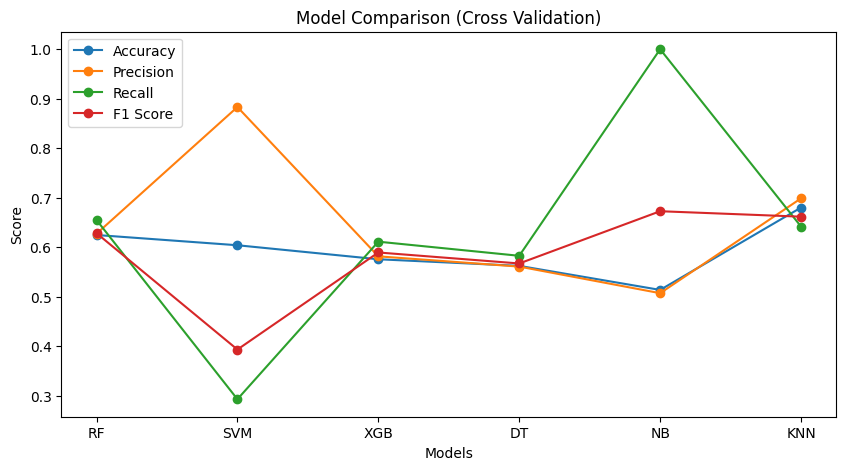

In [43]:
import matplotlib.pyplot as plt

models = ['RF', 'SVM', 'XGB', 'DT', 'NB', 'KNN']

accuracy = [0.6249, 0.6042, 0.5759, 0.5626, 0.5140, 0.6803]
precision = [0.6274, 0.8833, 0.5818, 0.5611, 0.5074, 0.6989]
recall = [0.6552, 0.2933, 0.6114, 0.5829, 1.0000, 0.6419]
f1 = [0.6286, 0.3936, 0.5896, 0.5674, 0.6729, 0.6619]

x = range(len(models))

plt.figure(figsize=(10,5))

plt.plot(x, accuracy, marker='o', label='Accuracy')
plt.plot(x, precision, marker='o', label='Precision')
plt.plot(x, recall, marker='o', label='Recall')
plt.plot(x, f1, marker='o', label='F1 Score')

plt.xticks(x, models)
plt.title('Model Comparison (Cross Validation)')
plt.xlabel('Models')
plt.ylabel('Score')
plt.legend()

plt.show()

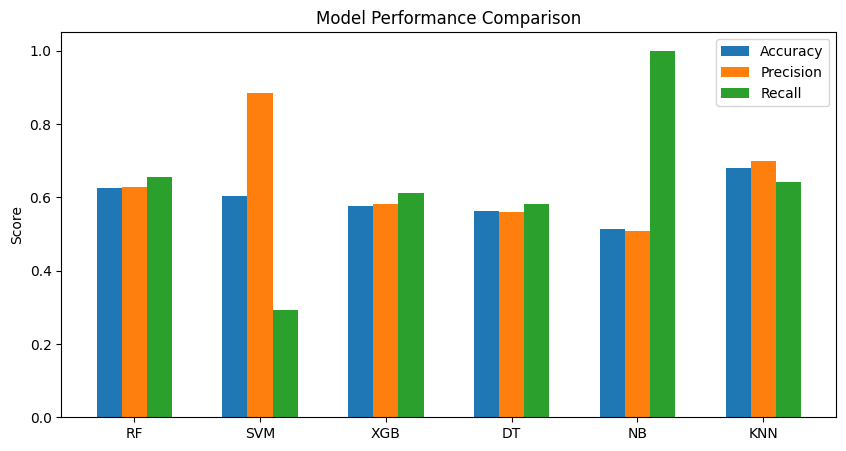

In [44]:
import numpy as np

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,5))

plt.bar(x - width, accuracy, width, label='Accuracy')
plt.bar(x, precision, width, label='Precision')
plt.bar(x + width, recall, width, label='Recall')

plt.xticks(x, models)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.legend()

plt.show()

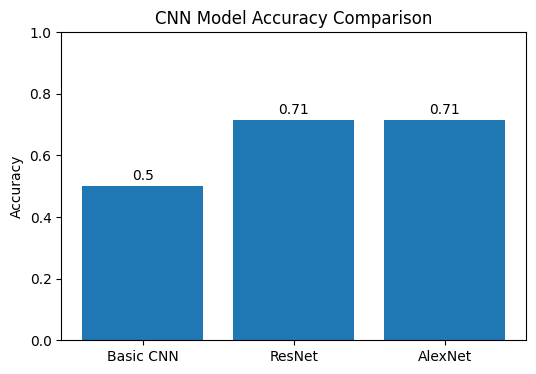

In [45]:
import matplotlib.pyplot as plt

models = ['Basic CNN', 'ResNet', 'AlexNet']
accuracy = [0.50, 0.7143, 0.7143]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)

plt.title('CNN Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0,1)

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.02, str(round(v,2)), ha='center')

plt.show()